In [2]:
import gzip
import json
import csv
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
DATA_URL = (
    "https://amazon-berkeley-objects.s3.us-east-1.amazonaws.com/"
    "listings/metadata/listings_0.json.gz"
)
LOCAL_FILE = "listings_0.json.gz"

FURNITURE_TYPES = {
    "CHAIR", "SOFA", "TABLE", "DESK", "BED", "BENCH",
    "BOOKCASE", "CABINET", "DRESSER", "WARDROBE", "SHELF",
    "OTTOMAN", "STOOL", "NIGHTSTAND", "DINING_TABLE",
}
 
INCH_TO_MM = 25.4

In [9]:
def download_data():
    """Download the ABO file if we don't already have it."""
    if os.path.exists(LOCAL_FILE):
        print(f"Already have {LOCAL_FILE}, skipping download.")
        return
    print("Downloading real ABO data (this may take a minute)...")
    urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
    print("Download done.")
 

## Raw Data

In [24]:

raw = []
with gzip.open("listings_0.json.gz", "rt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw.append(json.loads(line))

print(f"Total raw products in this file: {len(raw)}")

Total raw products in this file: 9232


In [33]:
raw[1]

{'item_dimensions': {'height': {'normalized_value': {'unit': 'inches',
    'value': 0.9},
   'unit': 'inches',
   'value': 0.9},
  'length': {'normalized_value': {'unit': 'inches', 'value': 22},
   'unit': 'inches',
   'value': 22},
  'width': {'normalized_value': {'unit': 'inches', 'value': 0.87},
   'unit': 'inches',
   'value': 0.87}},
 'brand': [{'language_tag': 'es_MX', 'value': 'AmazonBasics'}],
 'bullet_point': [{'language_tag': 'es_MX',
   'value': 'White Powder Coat Finish'},
  {'language_tag': 'es_MX', 'value': '55-Lbs max weight capacity'},
  {'language_tag': 'es_MX', 'value': 'Length: 22-inch (550mm)'},
  {'language_tag': 'es_MX',
   'value': 'Set includes 10 pair of slides; enough for 10 drawers'},
  {'language_tag': 'es_MX',
   'value': 'Mounting hardware and installation instructions included'}],
 'color': [{'language_tag': 'es_MX', 'value': 'White Powder Coat'}],
 'item_id': 'B07P8ML82R',
 'item_name': [{'language_tag': 'es_MX',
   'value': '22" Bottom Mount Drawer Slid

In [25]:
def english_value(field):
    if not field:
        return None
    for e in field:
        if e.get("language_tag", "").startswith("en"):
            return e.get("value")
    return field[0].get("value")

types = [english_value(item.get("product_type")) for item in raw]
types = pd.Series(types)

print(f"Total products: {len(types)}")
print(f"Unique product types: {types.nunique()}")

Total products: 9232
Unique product types: 335


In [26]:
counts = types.value_counts()
print(f"All {len(counts)} categories in the raw data:\n")
print(counts.head(30))   # top 30

All 335 categories in the raw data:

CELLULAR_PHONE_CASE           4103
SHOES                          762
GROCERY                        412
HOME                           343
HOME_BED_AND_BATH              202
HOME_FURNITURE_AND_DECOR       159
CHAIR                          125
FINERING                       120
BOOT                           115
SANDAL                         107
HEALTH_PERSONAL_CARE           100
ACCESSORY                       92
FINEEARRING                     80
FINENECKLACEBRACELETANKLET      75
OFFICE_PRODUCTS                 73
SOFA                            69
TABLE                           63
PET_SUPPLIES                    63
SPORTING_GOODS                  60
RUG                             56
LIGHT_BULB                      50
HARDWARE_HANDLE                 49
HANDBAG                         48
JANITORIAL_SUPPLY               45
KITCHEN                         45
HAT                             45
EARRING                         42
LAMP              

## Transform Data

In [10]:
def pick_english(field):
    """ABO fields are lists like [{language_tag, value}]. Grab the English one."""
    if not field:
        return None
    for entry in field:
        if entry.get("language_tag", "").startswith("en"):
            return entry.get("value")
    return field[0].get("value")

In [11]:

def get_dimension(dims, axis):
    """Return one dimension (width/length/height) in mm."""
    if not dims or axis not in dims:
        return None
    raw = dims[axis]
    value = raw.get("value")
    unit = raw.get("unit", "").lower()
    if value is None:
        return None
    if "inch" in unit:
        return round(value * INCH_TO_MM)
    if "centimeter" in unit:
        return round(value * 10)
    return round(value)
    

In [12]:
def parse_product(raw):
    """Convert one raw ABO record to our clean format, or None if not furniture."""
    ptype = pick_english(raw.get("product_type"))
    if ptype not in FURNITURE_TYPES:
        return None
    name = pick_english(raw.get("item_name"))
    if not name:
        return None
    dims = raw.get("item_dimensions")
    return {
        "id": raw.get("item_id"),
        "name": name,
        "category": ptype.lower(),
        "brand": pick_english(raw.get("brand")),
        "color": pick_english(raw.get("color")),
        "style": pick_english(raw.get("style")),
        "width_mm": get_dimension(dims, "width"),
        "depth_mm": get_dimension(dims, "length"),
        "height_mm": get_dimension(dims, "height"),
    }

In [13]:
 
def build_catalog():
    """Read the file and return a list of clean furniture products."""
    catalog = []
    with gzip.open(LOCAL_FILE, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            product = parse_product(json.loads(line))
            if product:
                catalog.append(product)
    return catalog

In [14]:

def save_catalog(catalog):
    """Save as both JSON (for code) and CSV (to open in Excel)."""
    with open("catalog.json", "w") as f:
        json.dump(catalog, f, indent=2)
 
    fields = ["id", "name", "category", "brand", "color", "style",
              "width_mm", "depth_mm", "height_mm"]
    with open("catalog.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(catalog)
 

In [16]:
 
def print_summary(catalog):
    """Print a short summary to show what we built."""
    print("\n" + "=" * 40)
    print(f"CATALOG BUILT: {len(catalog)} furniture products")
    print("=" * 40)
 
    # count per category
    counts = {}
    for p in catalog:
        counts[p["category"]] = counts.get(p["category"], 0) + 1
    print("\nProducts per category:")
    for cat, n in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {cat:15s} {n}")
 
    # how many have full dimensions
    with_dims = sum(1 for p in catalog
                    if p["width_mm"] and p["depth_mm"] and p["height_mm"])
    print(f"\nProducts with full dimensions: {with_dims} / {len(catalog)}")
 
    print("\nExample product:")
    for p in catalog:
        if p["width_mm"]:
            print(json.dumps(p, indent=2))
            break
 
    print("\nSaved to: catalog.csv  and  catalog.json")

In [17]:
download_data()
catalog = build_catalog()
save_catalog(catalog)
print_summary(catalog)

Already have listings_0.json.gz, skipping download.

CATALOG BUILT: 360 furniture products

Products per category:
  chair           125
  sofa            69
  table           63
  ottoman         26
  bed             19
  cabinet         18
  shelf           18
  desk            10
  dresser         7
  bench           5

Products with full dimensions: 307 / 360

Example product:
{
  "id": "B072ZLCB3M",
  "name": "Amazon Brand \u2013 Rivet Bristol Natural Edge Black Metal Side Table, Walnut",
  "category": "table",
  "brand": "Rivet",
  "color": "Brown",
  "style": "Organic modern",
  "width_mm": 462,
  "depth_mm": 480,
  "height_mm": 480
}

Saved to: catalog.csv  and  catalog.json


## Representing Data

In [5]:
df = pd.read_json("catalog.json")

print(f"Total products: {len(df)}")
print(f"Categories: {df['category'].nunique()}")
print(f"Brands: {df['brand'].nunique()}")
print(f"With full dimensions: {df.dropna(subset=['width_mm','depth_mm','height_mm']).shape[0]}")
df.head()

Total products: 360
Categories: 10
Brands: 26
With full dimensions: 309


,id,name,category,brand,color,style,width_mm,depth_mm,height_mm,volume_mm3,footprint_mm2,storage_score,room_types,storage_indicator
0,B07CTPR73M,"Stone & Beam Stone Brown Swatch, 25020039-01",sofa,Stone & Beam,Stone Brown,None,NaN,NaN,NaN,NaN,NaN,NaN,[living room],{'living room': '-'}
1,B072ZLCB3M,Amazon Brand – Rivet Bristol Natural Edge Blac...,table,Rivet,Brown,Organic modern,462.0,480.0,480.0,1.064448e+08,221760.0,74.0,"[living room, office]","{'living room': '+', 'office': '+'}"
2,B07TMH6289,AmazonBasics LeatherSoft Kids/Youth Recliner w...,chair,AmazonBasics,Light Blue,None,701.0,681.0,701.0,3.346441e+08,477381.0,60.0,"[office, living room, bedroom]","{'office': '+', 'living room': '-', 'bedroom':..."
3,B075X4QMW7,Amazon Brand – Rivet Eva Mid-Century Modern Tu...,sofa,Rivet,Navy,None,2210.0,895.0,768.0,1.519066e+09,1977950.0,10.0,[living room],{'living room': '-'}
4,B07F2X8K62,Amazon Brand – Ravenna Home Radford Modern Cur...,chair,Ravenna Home,None,None,NaN,NaN,NaN,NaN,NaN,NaN,"[office, living room, bedroom]","{'office': '-', 'living room': '-', 'bedroom':..."


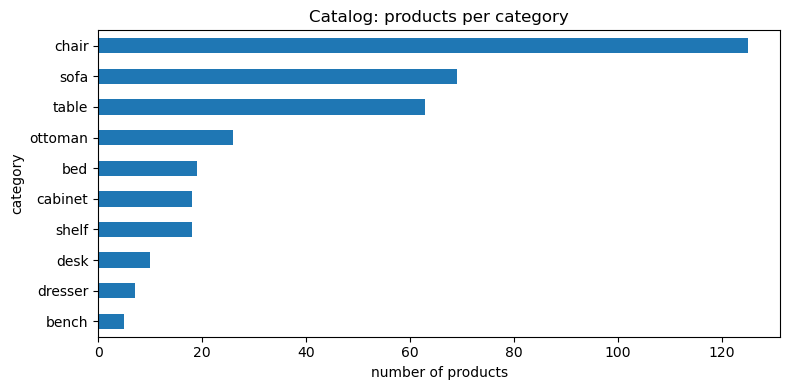

In [20]:
#products per category

counts = df["category"].value_counts()

plt.figure(figsize=(8, 4))
counts.plot(kind="barh")
plt.title("Catalog: products per category")
plt.xlabel("number of products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

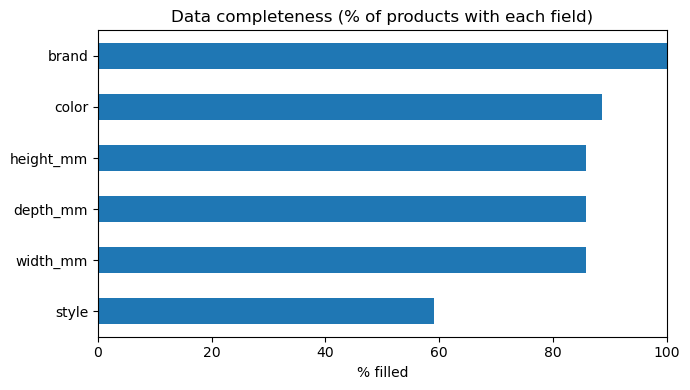

In [21]:
# data completeness

fields = ["brand", "color", "style", "width_mm", "depth_mm", "height_mm"]
completeness = df[fields].notna().mean() * 100   # % filled per field

plt.figure(figsize=(7, 4))
completeness.sort_values().plot(kind="barh")
plt.title("Data completeness (% of products with each field)")
plt.xlabel("% filled")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [22]:
# a real dimension insight

dims = df.dropna(subset=["width_mm", "depth_mm", "height_mm"])
print("Typical sizes by category (median, mm):")
dims.groupby("category")[["width_mm", "depth_mm", "height_mm"]].median().round().astype(int)

Typical sizes by category (median, mm):


,width_mm,depth_mm,height_mm
category,,,
bed,2140,1676,1422
bench,800,1260,555
cabinet,504,595,1235
chair,711,711,902
desk,595,1001,762
dresser,650,1524,889
ottoman,629,844,462
shelf,356,462,879
sofa,1008,1584,841


## Adding new attributes to catalog

### Storage Efficiency

In [44]:
df["volume_mm3"] = df["width_mm"] * df["depth_mm"] * df["height_mm"]
df["footprint_mm2"] = df["width_mm"] * df["depth_mm"]

# efficiency: tall items that don't eat floor score high
# (height rewarded, footprint penalised)
raw = df["height_mm"] / df["footprint_mm2"]

# rank-based: spreads scores evenly, ignores outlier squashing
df["storage_score"] = (raw.rank(pct=True) * 100).round(0)

df.groupby("category")["storage_score"].median().sort_values(ascending=False)

category
shelf      96.0
cabinet    80.5
chair      67.5
dresser    55.0
desk       49.0
ottoman    48.5
table      40.5
bench      26.0
sofa       17.5
bed         8.0
Name: storage_score, dtype: float64

In [45]:
df.head()

,id,name,category,brand,color,style,width_mm,depth_mm,height_mm,volume_mm3,footprint_mm2,storage_score
0,B07CTPR73M,"Stone & Beam Stone Brown Swatch, 25020039-01",sofa,Stone & Beam,Stone Brown,None,NaN,NaN,NaN,NaN,NaN,NaN
1,B072ZLCB3M,Amazon Brand – Rivet Bristol Natural Edge Blac...,table,Rivet,Brown,Organic modern,462.0,480.0,480.0,1.064448e+08,221760.0,74.0
2,B07TMH6289,AmazonBasics LeatherSoft Kids/Youth Recliner w...,chair,AmazonBasics,Light Blue,None,701.0,681.0,701.0,3.346441e+08,477381.0,60.0
3,B075X4QMW7,Amazon Brand – Rivet Eva Mid-Century Modern Tu...,sofa,Rivet,Navy,None,2210.0,895.0,768.0,1.519066e+09,1977950.0,10.0
4,B07F2X8K62,Amazon Brand – Ravenna Home Radford Modern Cur...,chair,Ravenna Home,None,None,NaN,NaN,NaN,NaN,NaN,NaN


### Room type

In [46]:
# which rooms each category sensibly belongs to
ROOM_TYPES = {
    "bed":      ["bedroom"],
    "dresser":  ["bedroom"],
    "sofa":     ["living room"],
    "ottoman":  ["living room"],
    "bench":    ["living room", "bedroom"],
    "desk":     ["office"],
    "chair":    ["office", "living room", "bedroom"],
    "table":    ["living room", "office"],
    "shelf":    ["office", "living room", "bedroom"],
    "cabinet":  ["office", "living room", "bedroom"],
}

df["room_types"] = df["category"].map(ROOM_TYPES)

# quick check: how many products available per room
from collections import Counter
counts = Counter()
for rooms in df["room_types"]:
    counts.update(rooms)

print(counts)

Counter({'living room': 324, 'office': 234, 'bedroom': 192})


In [47]:
df.head()

,id,name,category,brand,color,style,width_mm,depth_mm,height_mm,volume_mm3,footprint_mm2,storage_score,room_types
0,B07CTPR73M,"Stone & Beam Stone Brown Swatch, 25020039-01",sofa,Stone & Beam,Stone Brown,None,NaN,NaN,NaN,NaN,NaN,NaN,[living room]
1,B072ZLCB3M,Amazon Brand – Rivet Bristol Natural Edge Blac...,table,Rivet,Brown,Organic modern,462.0,480.0,480.0,1.064448e+08,221760.0,74.0,"[living room, office]"
2,B07TMH6289,AmazonBasics LeatherSoft Kids/Youth Recliner w...,chair,AmazonBasics,Light Blue,None,701.0,681.0,701.0,3.346441e+08,477381.0,60.0,"[office, living room, bedroom]"
3,B075X4QMW7,Amazon Brand – Rivet Eva Mid-Century Modern Tu...,sofa,Rivet,Navy,None,2210.0,895.0,768.0,1.519066e+09,1977950.0,10.0,[living room]
4,B07F2X8K62,Amazon Brand – Ravenna Home Radford Modern Cur...,chair,Ravenna Home,None,None,NaN,NaN,NaN,NaN,NaN,NaN,"[office, living room, bedroom]"


### Storage efficiency Indicator

In [50]:

rng = np.random.default_rng(42)

# the storage_score needed to earn a "+" in each room.
# lower cutoff = easier to get "+" = that room values storage more.
ROOM_CUTOFF = {
    "office":      40,   # easy to score + here, offices want storage
    "bedroom":     55,   # medium
    "living room": 70,   # hard to score + here, only great storage counts
}

def assign_indicators(row):
    result = {}
    for room in row["room_types"]:
        if row["storage_score"] >= ROOM_CUTOFF[room]:
            result[room] = "+"
        else:
            result[room] = "-"
    return result

df["storage_indicator"] = df.apply(assign_indicators, axis=1)

In [52]:
df[df["category"].isin(["cabinet", "table"])][
    ["name", "category", "storage_score", "room_types", "storage_indicator"]
].head(8)

,name,category,storage_score,room_types,storage_indicator
1,Amazon Brand – Rivet Bristol Natural Edge Blac...,table,74.0,"[living room, office]","{'living room': '+', 'office': '+'}"
10,Amazon Brand – Ravenna Home Angela Modern Turn...,table,37.0,"[living room, office]","{'living room': '-', 'office': '-'}"
17,"Vida Designs Corona Wardrobe, 3 Door, Solid Pi...",cabinet,78.0,"[office, living room, bedroom]","{'office': '+', 'living room': '+', 'bedroom':..."
22,Marchio Amazon - Alkove Hayes - Tavolo da pran...,table,31.0,"[living room, office]","{'living room': '-', 'office': '-'}"
35,Amazon Brand - Solimo Mars Engineered Wood Bed...,table,85.0,"[living room, office]","{'living room': '+', 'office': '+'}"
39,"Amazon Brand – Rivet Modern End Table, 19.3 In...",table,77.0,"[living room, office]","{'living room': '+', 'office': '+'}"
40,"Marchio Amazon - Movian, credenza a 2 sportell...",cabinet,84.0,"[office, living room, bedroom]","{'office': '+', 'living room': '+', 'bedroom':..."
41,Amazon Brand - Alkove Hayes Classic Fixed Soli...,table,30.0,"[living room, office]","{'living room': '-', 'office': '-'}"


In [53]:
mid = df[(df["storage_score"] >= 40) & (df["storage_score"] < 70)]
mid[mid["room_types"].apply(lambda r: "office" in r and "living room" in r)][
    ["name", "category", "storage_score", "storage_indicator"]
].head(5)

,name,category,storage_score,storage_indicator
2,AmazonBasics LeatherSoft Kids/Youth Recliner w...,chair,60.0,"{'office': '+', 'living room': '-', 'bedroom':..."
13,AmazonBasics Classic Faux Leather Extra Padded...,chair,53.0,"{'office': '+', 'living room': '-', 'bedroom':..."
19,Amazon Brand – Ravenna Home Tufted Armless Eng...,chair,67.0,"{'office': '+', 'living room': '-', 'bedroom':..."
34,Strathwood All-Weather Wicker Deep Seating Out...,chair,60.0,"{'office': '+', 'living room': '-', 'bedroom':..."
47,Ravenna Home Classic Plank-Top Console Table w...,table,66.0,"{'living room': '-', 'office': '+'}"


In [54]:
df.head()

,id,name,category,brand,color,style,width_mm,depth_mm,height_mm,volume_mm3,footprint_mm2,storage_score,room_types,storage_indicator
0,B07CTPR73M,"Stone & Beam Stone Brown Swatch, 25020039-01",sofa,Stone & Beam,Stone Brown,None,NaN,NaN,NaN,NaN,NaN,NaN,[living room],{'living room': '-'}
1,B072ZLCB3M,Amazon Brand – Rivet Bristol Natural Edge Blac...,table,Rivet,Brown,Organic modern,462.0,480.0,480.0,1.064448e+08,221760.0,74.0,"[living room, office]","{'living room': '+', 'office': '+'}"
2,B07TMH6289,AmazonBasics LeatherSoft Kids/Youth Recliner w...,chair,AmazonBasics,Light Blue,None,701.0,681.0,701.0,3.346441e+08,477381.0,60.0,"[office, living room, bedroom]","{'office': '+', 'living room': '-', 'bedroom':..."
3,B075X4QMW7,Amazon Brand – Rivet Eva Mid-Century Modern Tu...,sofa,Rivet,Navy,None,2210.0,895.0,768.0,1.519066e+09,1977950.0,10.0,[living room],{'living room': '-'}
4,B07F2X8K62,Amazon Brand – Ravenna Home Radford Modern Cur...,chair,Ravenna Home,None,None,NaN,NaN,NaN,NaN,NaN,NaN,"[office, living room, bedroom]","{'office': '-', 'living room': '-', 'bedroom':..."


In [55]:
df.to_json("catalog.json", orient="records", indent=2)
print("Saved catalog with new attributes:", df.columns.tolist())

Saved catalog with new attributes: ['id', 'name', 'category', 'brand', 'color', 'style', 'width_mm', 'depth_mm', 'height_mm', 'volume_mm3', 'footprint_mm2', 'storage_score', 'room_types', 'storage_indicator']


### Adding Size Category

In [6]:
df = df[(df[["width_mm","depth_mm","height_mm"]] > 0).all(axis=1)]
df = df[(df[["width_mm","depth_mm","height_mm"]] <= 3000).all(axis=1)]

In [7]:
# tag each product S/M/L by volume, within its own category
df["volume"] = df["width_mm"] * df["depth_mm"] * df["height_mm"]

def size_band(group):
    # split this category's items into 3 equal groups by volume
    return pd.qcut(group["volume"], 3, labels=["S", "M", "L"])

df["size"] = df.groupby("category", group_keys=False).apply(size_band)

# build the range table: min-max of each dimension per category + size
table = df.groupby(["category", "size"]).agg(
    count=("id", "size"),
    width=("width_mm", lambda x: f"{int(x.min())}-{int(x.max())}"),
    depth=("depth_mm", lambda x: f"{int(x.min())}-{int(x.max())}"),
    height=("height_mm", lambda x: f"{int(x.min())}-{int(x.max())}"),
)
table

/var/folders/cl/cxlwmrcx6y73rqxnxccllqgm0000gn/T/ipykernel_25090/515377653.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["size"] = df.groupby("category", group_keys=False).apply(size_band)
/var/folders/cl/cxlwmrcx6y73rqxnxccllqgm0000gn/T/ipykernel_25090/515377653.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(["category", "size"]).agg(


count      width      depth     height
category size                                        
bed      S         6   559-1950   406-1995   130-1643
         M         7  1422-2337  1499-2159  1075-1968
         L         4  2140-2337  2045-2280  1422-1470
bench    S         1    400-400  1180-1180    500-500
         M         1    800-800  1260-1260    579-579
         L         1  1554-1554  1854-1854    555-555
cabinet  S         6    192-750    250-643   599-1770
         M         6   400-1200   400-1650   500-1910
         L         6   600-3000   483-1830   914-2360
chair    S        33    360-876   360-1067   298-1080
         M        33    565-864   550-1150   701-1285
         L        34   700-2210   725-2120   770-1372
desk     S         3   440-1100   560-1001    730-762
         M         3    342-595   762-1400   760-1829
         L         3    670-940   940-1580    760-986
dresser  S         3   410-1549    432-800    730-864
         M         2    457-483  1524-1524    889-914
         L         2   650-2210  1940-2500   940-2180
ottoman  S         8   366-1200    120-838    270-480
         M        10   432-1280   495-1219    406-711
         L         6   880-1003   831-2210    438-960
shelf    S         5    120-572    146-600     70-594
         M         5     76-864    290-610   610-1633
         L         5    356-718   356-1575   457-1880
sofa     S        19   790-2000   480-1930    178-940
         M        19   813-2210   813-2280   681-1016
         L        19   787-2337   920-2286   762-2413
table    S        19      1-610   325-1219    334-719
         M        18   480-1501   399-1279    129-710
         L        19   450-1100   406-2250    400-914

In [8]:
table.to_csv("size_bands.csv")